### Dynamic Time Warping Analysis of the IF segments

This notebook illustrates how DTW can be used to analyze the IF segments.

For the illustration we consider data from ILL18 for 2018. We note the following:

1. Data should be contained in the folder "../data/XP/2018/ILL18/HHZ.D".
2. Output is stored in the folder "../output/illustration"
3. The debris-flow catalog is contained in "../catalogs/XP/initial_catalog.csv". 
4. Please work through the if_illustration.ipynb notebook first.

In [125]:
# Imports
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import multiprocessing as mp
import pickle

from tqdm import tqdm
from joblib import load
from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_template,
    extract_split_flows,
    limit_segment_length,
)
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid

from seismicif.dtw import (
    distribute_pairwise_segment_dtw,
    distribute_reference_segment_dtw,
    remove_singleton_merges,
)

from seismicif.metrics import (
    iou,
    est_thresholds,
    extract_valid_segments,
)

### Unsupervised Analysis

We use the IF segments generated in the if_illustation.ipynb notebook with the calibrated thresholds for illustration.

In [126]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/illustration/ILL18_mod.joblib")
if_segments_df = pd.read_csv("../output/illustration/ILL18_segments.csv", index_col=0)
n = if_segments_df.shape[0]
print(f"Number of IF segments: {n}")

Number of IF segments: 264


Since the number of IF segments is greater than 200, we first perform a pre-clustering of the leading 200 segments to indentify reference segments.

1. Perform segment DTW between all pairs of IF segments.
2. Construct a dendrogram using complete linkage.
3. Use the hybrid dynamic tree cut algorithm to identify clusters in the hierarchical tree.
4. Extract the leading IF segment in each identified cluster as a reference segment.

In [130]:
n = min(n, 200)

try:
    with open("../output/illustration/ILL18_pairwise.pkl", "rb") as f:
        indices, results = pickle.load(f)

except:
    if_segments = []
    for i in tqdm(range(n), desc="ILL18: Limiting IF segment lengths"):
        if_segments.append(
            limit_segment_length(
                if_segments_df["start"][i],
                if_segments_df["stop"][i],
                stream_paths,
                if_mod,
            )
        )

    indices = [(i, j, if_segments) for i in range(n) for j in range(i + 1, n)]

    with mp.Pool(mp.cpu_count()) as pool:
        results = list(
            tqdm(
                pool.imap(distribute_pairwise_segment_dtw, indices),
                total=len(indices),
                desc="ILL18: Performing Pairwise Segment DTW",
            )
        )

    indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

    with open("../output/illustration/ILL18_pairwise.pkl", "wb") as f:
        pickle.dump([indices, results], f)

ILL18: Performing Pairwise Segment DTW:  15%|█▍        | 2977/19900 [39:05<3:42:13,  1.27it/s] 


KeyboardInterrupt: 

In [68]:
n = max(indices)[1] + 1
D = np.zeros([n, n])

for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

D = squareform(D)
Z = linkage(D, method="complete")
# use the hybrid dynamic tree cut algorithm to identify clusters in the hierarchical tree
clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)

..cutHeight not given, setting it to 10207.642417568326  ===>  99% of the (truncated) height range in dendro.
..done.


In [69]:
# debris flow cluster was identified as cluster 2
if_segments_df.iloc[clusters["labels"] == 2]

,start,stop,most_anomalous_start,scores
2,2018-07-25T16:50:03.520019Z,2018-07-25T17:42:33.520019Z,2018-07-25T16:56:43.520019Z,0.790767
4,2018-08-08T17:44:13.580002Z,2018-08-08T18:09:13.580002Z,2018-08-08T17:49:13.580002Z,0.788184
16,2018-10-29T14:25:55.470000Z,2018-10-29T17:15:55.470000Z,2018-10-29T15:24:15.470000Z,0.771432
21,2018-06-11T10:30:53.740003Z,2018-06-11T11:27:33.740003Z,2018-06-11T10:47:33.740003Z,0.766193
27,2018-06-12T18:00:03.740003Z,2018-06-12T20:20:53.740003Z,2018-06-12T18:02:33.740003Z,0.751712
30,2018-10-29T22:40:05.470000Z,2018-10-30T00:54:15.470000Z,2018-10-29T22:45:55.470000Z,0.747203


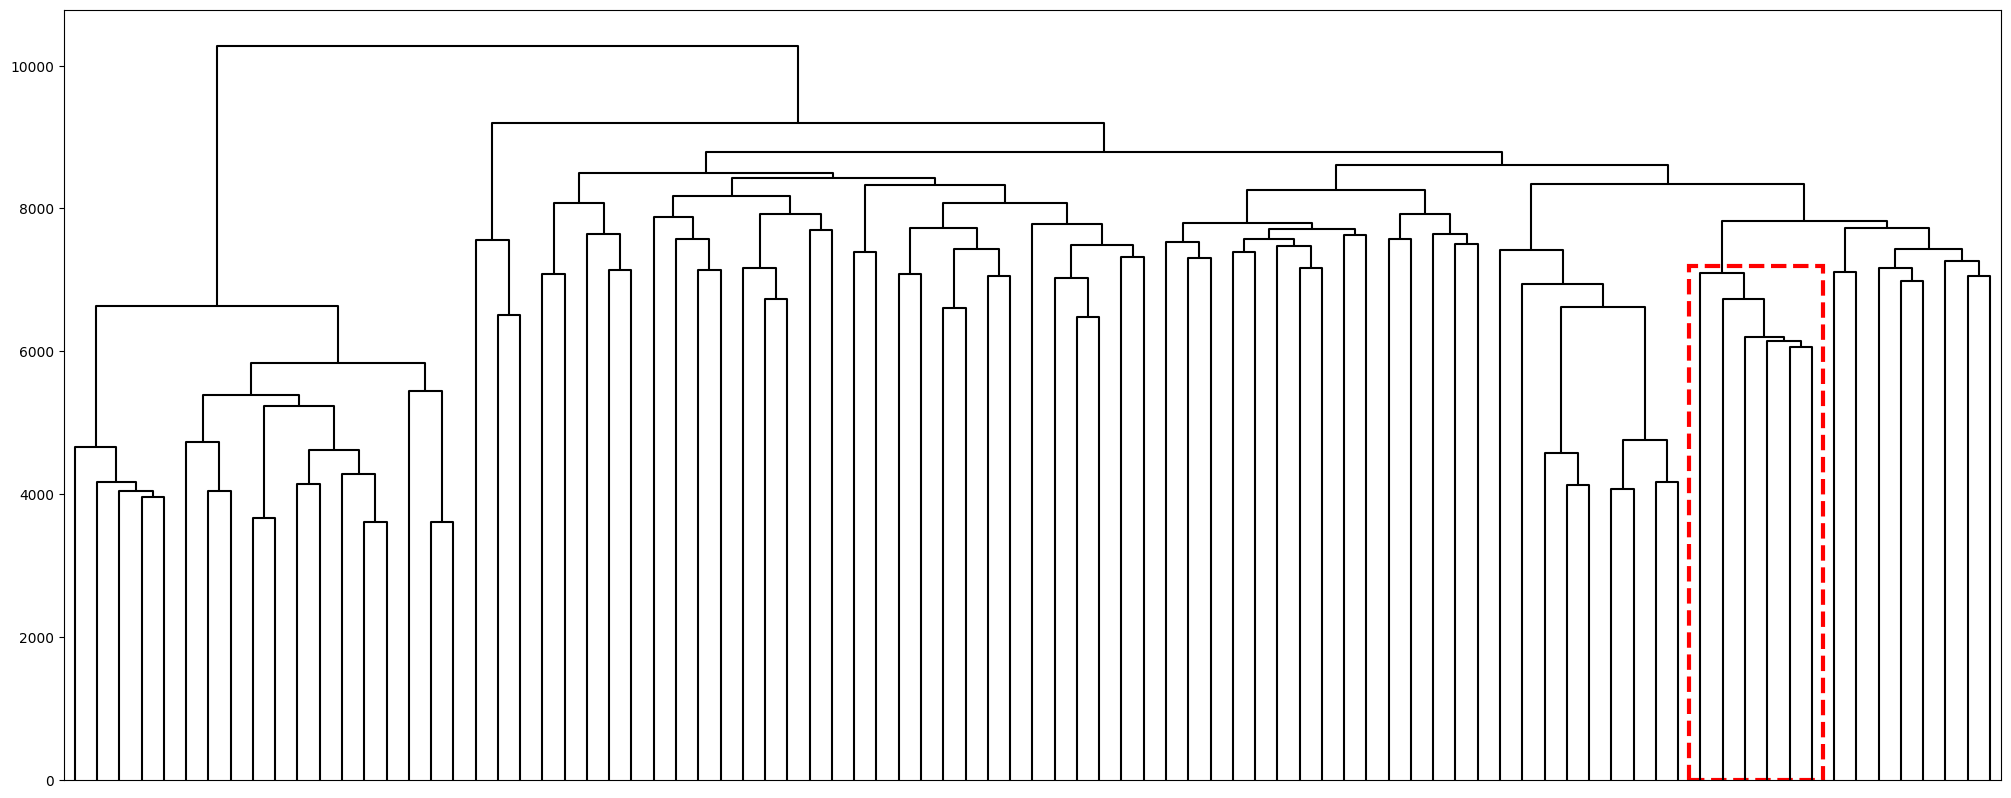

In [70]:
# illustrate linkaga with a dendrogram, red box highlights the debris-flow cluster
fig, ax = plt.subplots(figsize=(25, 10))

ddata = dendrogram(
    Z, no_labels=True, color_threshold=0, link_color_func=lambda k: "black", ax=ax
)

leaves = ddata["leaves"]
xpos = {leaf: 5 + 10 * i for i, leaf in enumerate(leaves)}

xs = [xpos[i] for i in idx]
xmin = min(xs) - 5
xmax = max(xs) + 5

root, nodes = to_tree(Z, rd=True)
idx_set = set(idx)


def leaves_under(node):
    if node.is_leaf():
        return {node.id}
    return leaves_under(node.left) | leaves_under(node.right)


for node in nodes:
    if not node.is_leaf():
        if leaves_under(node) == idx_set:
            cluster_height = node.dist
            break
cluster_height += 100

rect = Rectangle(
    (xmin, 0),
    xmax - xmin,
    cluster_height,
    fill=False,
    edgecolor="red",
    linewidth=3,
    linestyle="--",
)

ax.add_patch(rect)

plt.show()

### Semi-supervised Analysis

We use the IF segments generated in the if_illustation.ipynb notebook with the calibrated thresholds for illustration.

Notes. 

1. The semi-supervised approach is aimed at searching the IF segments for waveforrm segments similar to those contained in a catalog.
2. In the initial WSL catalog there are only 3 high-comfidence segments for ILL18 during 2018. Due to this small number we did not check for singleton merges as described in the paper.

In [ ]:
# extract reference segments as the high confidence events in the catalog
events = preproc_flow_annotations(pd.read_csv("../catalogs/XP/initial_catalog.csv"))
_, high_conf_events, _ = extract_split_flows(events, "ILL18", 2018, 2018)

ref_segments = []
for i in tqdm(
    range(high_conf_events.shape[0]), desc="ILL18: Limiting reference segment lengths"
):
    ref_segments.append(
        limit_segment_length(
            high_conf_events["start"][i],
            high_conf_events["stop"][i],
            stream_paths,
            if_mod,
        )
    )

# create dataframe of reference segments with start and stop times for later use
ref_segments_df = pd.DataFrame(
    {"start": [i[2] for i in ref_segments], "stop": [i[3] for i in ref_segments]}
)

In [ ]:
paired_segments = []

for i in tqdm(
    range(if_segments_df.shape[0]), desc="ILL18: Limiting IF segment lengths"
):
    paired_segments.append(
        (
            limit_segment_length(
                if_segments_df["start"][i],
                if_segments_df["stop"][i],
                stream_paths,
                if_mod,
            ),
            ref_segments,
        )
    )

with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_reference_segment_dtw, paired_segments),
            total=len(paired_segments),
            desc="ILL18: Performing Reference Segment DTW",
        )
    )

with open("../output/illustration/ILL18_ref.pkl", "wb") as f:
    pickle.dump(results, f)

ILL18: Limiting IF segment lengths: 100%|██████████| 87/87 [00:39<00:00,  2.19it/s]


ILL18: Performing Reference Segment DTW: 100%|██████████| 87/87 [05:13<00:00,  3.60s/it]  


In [89]:
X = np.zeros((len(results), len(results[0])))

In [93]:
dtw_segments_df = if_segments_df.copy()

In [106]:
ref_segments[0][2]

2018-06-12T18:11:40.000000Z

In [107]:
ref_segments[0][3]

2018-06-12T18:41:40.000000Z

In [101]:
ref_segments_df = preproc_flow_annotations(ref_segments_df)

TypeError: list indices must be integers or slices, not str

In [113]:
for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])
    cummulative_intersections, _, _ = iou(
        ref_segments_df, dtw_segments_df.iloc[[i]].reset_index(drop=True)
    )
    intersection_lengths = np.append(
        cummulative_intersections[0], np.diff(cummulative_intersections)
    )
    overlap_idx = np.where(intersection_lengths > 0)[0]
    X[i, overlap_idx] = np.nan

In [115]:
dtw_segments_df["scores"] = np.nanmean(X, axis=1)

In [120]:
dtw_segments_df.iloc[np.argsort(dtw_segments_df["scores"])].head()

,start,stop,most_anomalous_start,scores
16,2018-10-29T14:25:55.470000Z,2018-10-29T17:15:55.470000Z,2018-10-29T15:24:15.470000Z,6296.597352
30,2018-10-29T22:40:05.470000Z,2018-10-30T00:54:15.470000Z,2018-10-29T22:45:55.470000Z,6317.058310
2,2018-07-25T16:50:03.520019Z,2018-07-25T17:42:33.520019Z,2018-07-25T16:56:43.520019Z,6348.486971
4,2018-08-08T17:44:13.580002Z,2018-08-08T18:09:13.580002Z,2018-08-08T17:49:13.580002Z,6541.881126
21,2018-06-11T10:30:53.740003Z,2018-06-11T11:27:33.740003Z,2018-06-11T10:47:33.740003Z,6615.115503


In [91]:
ref_segments_df = ref_segments

In [ ]:
# Todo: if there is an error below it is probably because the input eval period does not cover the if segment period. Need to add error handling for this.



In [ ]:
try:
    with open(f"{dtw_path}/{args.station}_pairwise", "rb") as f:
        indices, results = pickle.load(f)
        print(f"{args.station}: Loaded Existing Pairwise DTW Results")

except FileNotFoundError:
    with mp.Pool(mp.cpu_count()) as pool:
        results = list(
            tqdm(
                pool.imap(distribute_pairwise_segment_dtw, indices),
                total=len(indices),
                desc=f"{args.station}: Performing Pairwise Segment DTW",
            )
        )

        indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

    with open(f"{dtw_path}/{args.station}_pairwise", "wb") as f:
        pickle.dump([indices, results], f)

nseg = max(indices)[1] + 1
D = np.zeros([nseg, nseg])

for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

idx = remove_singleton_merges(D)

ref_segments = {
    "start": [i[2] for i in ref_segments],
    "stop": [i[3] for i in ref_segments],
    "include": np.repeat("no", n),
}
ref_segments = pd.DataFrame(ref_segments)
ref_segments.loc[idx, "include"] = "yes"
ref_segments.to_csv(f"{dtw_path}/{args.station}.csv", index=False)

In [ ]:
ref_segments = []
for i in tqdm(
    range(high_conf_events.shape[0]),
    desc=f"{args.station}: Limiting reference segment lengths",
):
    ref_segments.append(
        limit_segment_length(
            high_conf_events["start"][i], high_conf_events["stop"][i], paths, if_mod
        )
    )

n = len(ref_segments)
indices = [(i, j, ref_segments) for i in range(n) for j in range(i + 1, n)]

First we extract templates from the high-confidence segments

In [26]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/XP/if/models/ILL18_illustration.joblib")
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, all_flows = extract_split_flows(
    flows, "ILL18", 2018, 2018
)

templates = []
for i in range(high_conf_flows.shape[0]):
    t0 = high_conf_flows["start"][i]
    t1 = high_conf_flows["stop"][i]
    templates.append(extract_template(t0, t1, if_mod, stream_paths))
templates = np.array(templates)

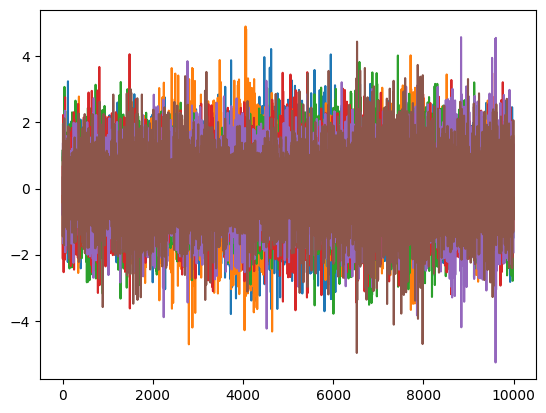

In [27]:
for tem in templates:
    plt.plot(tem)

When performing DTW we only consider segments flagged by the IF trigger. 

In [28]:
if_segments = preproc_flow_annotations(
    pd.read_csv("../output/XP/if/segments/ILL18_illustration.csv", index_col=0)
)

Compute the template DTW distances of IF segments w.r.t. all high-confidence segments.

In [32]:
try:
    dtw_dists = np.load("../output/XP/if_dtw/distances/ILL18_illustration.npy")

except (FileNotFoundError, OSError):
    dtw_dists = []
    for i in tqdm(range(if_segments.shape[0])):
        dtw_dists.append(
            template_dtw(
                if_segments["start"][i],
                if_segments["stop"][i],
                stream_paths,
                templates,
                if_mod,
            )
        )
    dtw_dists = np.array(dtw_dists)

    np.save("../output/XP/if_dtw/distances/ILL18_illustration", dtw_dists)

For each segment flagged by the IF trigger we compute the mean of the DTW distances w.r.t the templates. However, if a flagged segment overlaps with a high-confidence segment the DTW distance w.r.t the corresponding template is excluded.

We replace the IF segment anomaly score with the DTW score and sort the segments in increasing order.

In [33]:
dtw_scores = []

for i in range(dtw_dists.shape[0]):
    intersection, _, _ = iou(
        high_conf_flows, if_segments.loc[[i]].reset_index(drop=True)
    )
    high_conf_overlap = np.append(intersection[0], np.diff(intersection)) > 0
    dtw_scores.append(np.mean(dtw_dists[i, ~high_conf_overlap]))

dtw_segments = if_segments.copy()
dtw_segments["scores"] = dtw_scores
dtw_segments = dtw_segments.iloc[np.argsort(dtw_segments["scores"])].reset_index(
    drop=True
)

When calibrating the minimum detection length and score thresholds we compare (a) only detections overlapping with a high confidence segment or no lower-confidence segments with (b) high confidence segments.

In [34]:
valid_segments = extract_valid_segments(dtw_segments, lower_conf_flows, high_conf_flows)
# mode ="upper" to indicate that segments are sorted in ascending order of DTW score
iou_val, min_len, score_thres = est_thresholds(
    valid_segments, high_conf_flows, mode="upper"
)
print(f"detection iou: {100 * iou_val:.2f}%")

detection iou: 53.32%


In [35]:
detections = dtw_segments.copy()
start_times = np.array([pd.to_datetime(str(i)) for i in detections["start"]])
end_times = np.array([pd.to_datetime(str(i)) for i in detections["stop"]])
det_lens = np.array([i.total_seconds() for i in end_times - start_times])
detections = detections.assign(det_lens=det_lens)
detections = detections[
    (detections["scores"] < score_thres) & (detections["det_lens"] > min_len)
].reset_index(drop=True)
print(detections.head())

                         start                         stop       scores  \
0  2018-10-29T22:40:05.470000Z  2018-10-29T23:35:55.470000Z  5977.449394   
1  2018-10-29T15:15:55.470000Z  2018-10-29T16:58:25.470000Z  5978.635462   
2  2018-07-25T16:50:03.520019Z  2018-07-25T17:29:13.520019Z  6118.684793   
3  2018-10-29T14:25:05.470000Z  2018-10-29T15:05:55.470000Z  6298.216707   
4  2018-06-11T10:15:53.740003Z  2018-06-11T11:09:13.740003Z  6595.126678   

   det_lens  
0    3350.0  
1    6150.0  
2    2350.0  
3    2450.0  
4    3200.0  
